# Bellabeat Case Study  
## How Can a Wellness Technology Company Play It Smart?

**Author:** Ayodeji Emmanuel Monehin  
**Tools:** R / Google Sheets logic  
**Dataset:** Fitbit Fitness Tracker Data (Kaggle)

**Data Storytelling Presentation:**  
https://docs.google.com/presentation/d/1km9ueqBwvnIh8knK1P0ktUl28nuDgNK2gjpJ_VS4W1g/edit?usp=sharing

## 1. Business Task

The objective of this analysis is to examine smart device usage data to identify
patterns in wearable engagement and apply these insights to inform Bellabeat’s
marketing strategy, with a focus on the Bellabeat Leaf wellness tracker.
## 2. Data Description

This analysis uses publicly available Fitbit Fitness Tracker data made available by Mobius on Kaggle. The dataset contains daily and hourly wearable data from 33 users who consented to the use of their activity tracking information. These datasets were generated by respondents to a distributed survey via Mechanical Turk between 03-12-2016 and 05-12-2016. Available to us are 18 (.csv) files containing different quantitative data tracked by Fitbit such as minute-level output for physical activity, heart rate, sleep monitoring, etc.

### Datasets Used
The following datasets were used:
- Daily Activity Data: steps, distance, and sedentary minutes
- Sleep Data: total minutes asleep and sleep logging frequency
- Hourly Intensity Data: activity intensity by hour of the day

These datasets were selected because they closely align with the core features of the Bellabeat Leaf, which tracks daily activity, sleep, and movement intensity. 

## 3. Data Cleaning and Preparation

Google Sheets was used for data cleaning and aggregation due to the manageable size of the selected datasets and the need for transparency in the cleaning process.
Key cleaning steps included:
- Formatting date fields for consistency
- Filtering for valid usage days
- Identifying and excluding non-wear days
  
Days where sedentary minutes or total steps were equal to zero were treated as non-usage days, as these values indicate incomplete or missing wearable usage rather than true inactivity. These days were excluded from behavioural analysis to ensure data validity.
All cleaning and aggregation steps were documented using pivot tables and supporting notes.
- Link: https://docs.google.com/spreadsheets/d/1exXJKbvI_kkAcpE-7xjBoTLYIUK74gUtP6N9pL6E2qY/edit?usp=sharing

## 4. Analysis


In [1]:
# Load required libraries
library(tidyverse)
library(lubridate)


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     


── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [2]:
# Import daily activity data
daily_activity <- read_csv("/kaggle/input/fitbit/mturkfitbit_export_4.12.16-5.12.16/Fitabase Data 4.12.16-5.12.16/dailyActivity_merged.csv")

# Filter valid usage days
daily_valid <- daily_activity %>%
  filter(TotalSteps > 0)


Rows: 940 Columns: 15


── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (1): ActivityDate
dbl (14): Id, TotalSteps, TotalDistance, TrackerDistance, LoggedActivitiesDi...



ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


### 4.1 Wearable Usage Consistency Across Users

In [3]:
#aggregate average steps and count of valid days per user
steps_by_user <- daily_valid %>%
  group_by(Id) %>%
  summarise(
    avg_steps = mean(TotalSteps),
    valid_days = n()
  )


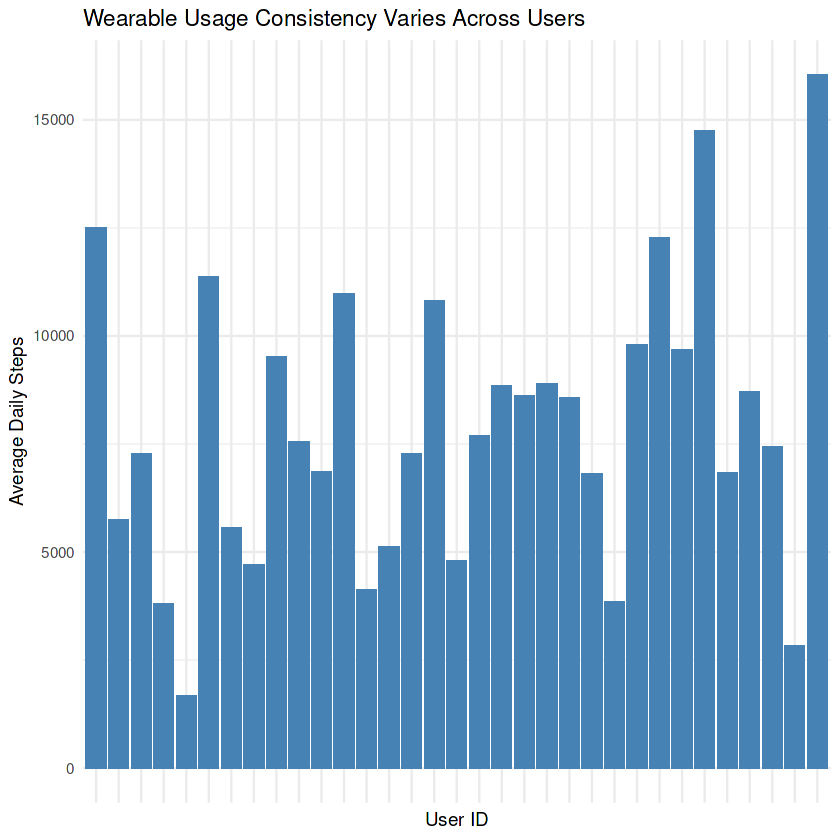

In [4]:
#Visualize variation in wearable usage consistency across
ggplot(steps_by_user, aes(x = factor(Id), y = avg_steps)) +
  geom_col(fill = "steelblue") +
  labs(
    title = "Wearable Usage Consistency Varies Across Users",
    x = "User ID",
    y = "Average Daily Steps"
  ) +
  theme_minimal() +
  theme(
    axis.text.x = element_blank(),
      # Hide IDs to reduce clutter
    axis.ticks.x = element_blank()
  )


Average daily steps and the number of valid activity days were aggregated per user.
The results show large variation in both activity levels and usage consistency.

This indicates differing levels of engagement and habit formation among wearable
device users.


### 4.2 Daily Rhythm of Physical Activity

In [5]:
# Import hourly intensity data
hourly_intensity <- read_csv("/kaggle/input/fitbit/mturkfitbit_export_4.12.16-5.12.16/Fitabase Data 4.12.16-5.12.16/hourlyIntensities_merged.csv")
# Convert datetime column and extract hour of day
hourly_clean <- hourly_intensity %>%
  mutate( ActivityHour = mdy_hms(ActivityHour),
    hour = hour(ActivityHour)
  )


Rows: 22099 Columns: 4


── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (1): ActivityHour
dbl (3): Id, TotalIntensity, AverageIntensity



ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [6]:
# Calculate average intensity for each hour of the day
intensity_by_hour <- hourly_clean %>%
  group_by(hour) %>%
  summarise(avg_intensity = mean(TotalIntensity))


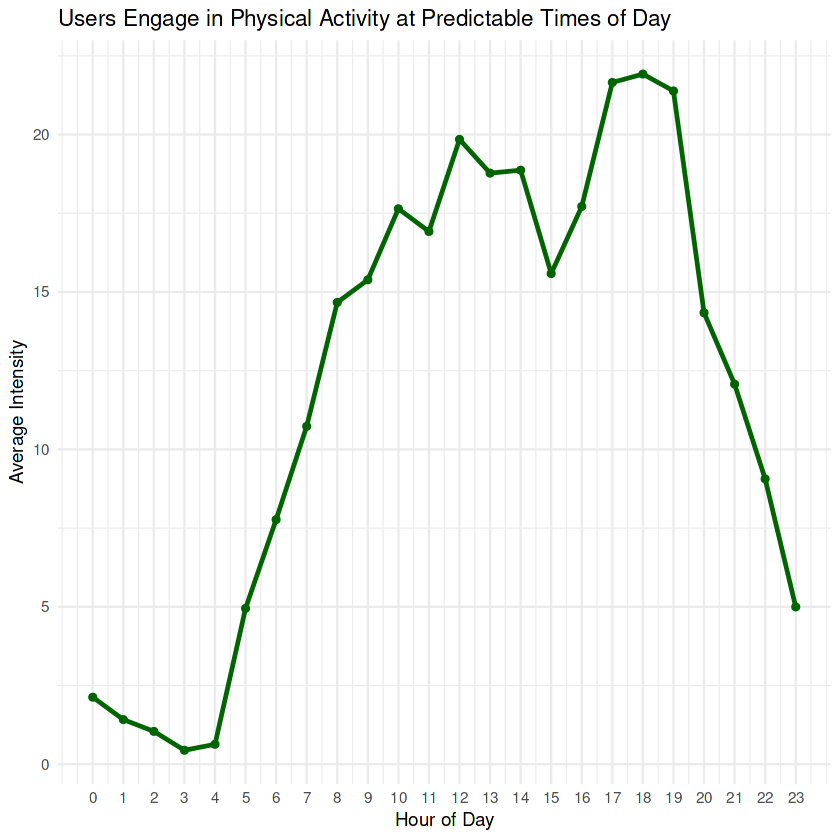

In [7]:
#Visualize predictable daily activity patterns
ggplot(intensity_by_hour, aes(x = hour, y = avg_intensity)) +
  geom_line(color = "darkgreen", linewidth = 1) +
  geom_point(color = "darkgreen") +
  scale_x_continuous(breaks = 0:23) +
  labs(
    title = "Users Engage in Physical Activity at Predictable Times of Day",
    x = "Hour of Day",
    y = "Average Intensity"
  ) +
  theme_minimal()


Hourly intensity data was aggregated by hour of the day. User activity shows
predictable peaks and low points throughout the day, forming a consistent
daily rhythm.

These patterns suggest opportunities for time-based engagement strategies.

### 4.3 Engagement With Wearable Features


In [8]:
# Import sleep tracking data
sleep_data <- read_csv("/kaggle/input/fitbit/mturkfitbit_export_4.12.16-5.12.16/Fitabase Data 4.12.16-5.12.16/sleepDay_merged.csv")

# Count number of valid activity logs per user
activity_logs <- daily_activity %>%
  group_by(Id) %>%
  summarise(activity_log_count = n())
#Count number of sleep logs per user
sleep_logs <- sleep_data %>%
  group_by(Id) %>%
  summarise(sleep_log_count = n())


Rows: 413 Columns: 5


── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (1): SleepDay
dbl (4): Id, TotalSleepRecords, TotalMinutesAsleep, TotalTimeInBed



ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


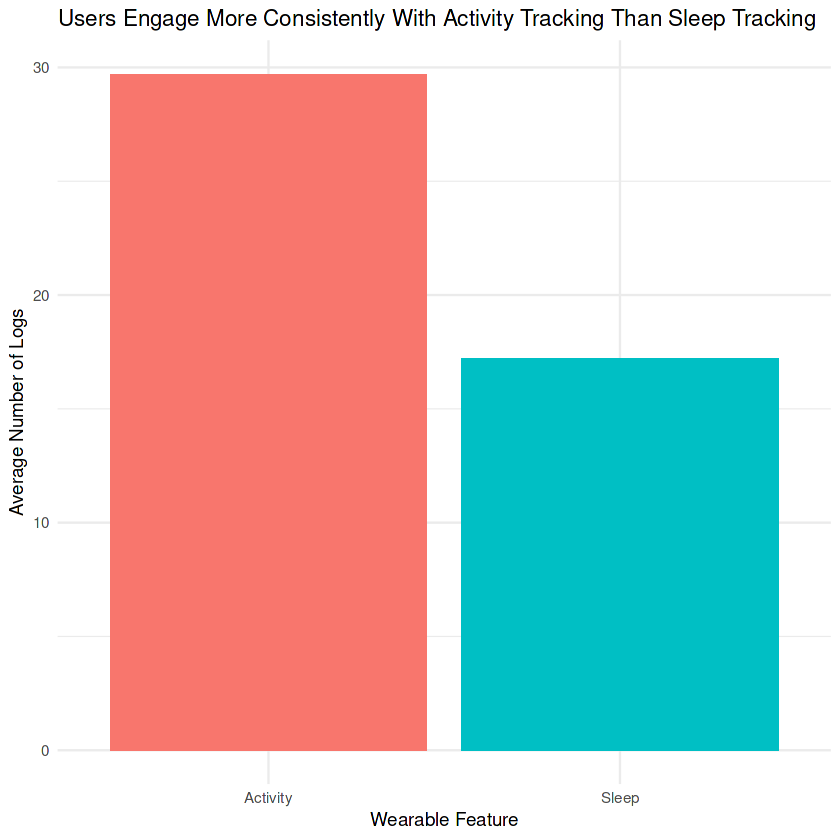

In [9]:
#Summarise engagement at the feature level for comparison
feature_engagement <- activity_logs %>%
  inner_join(sleep_logs, by = "Id") %>%
  summarise(
    Activity = mean(activity_log_count),
    Sleep = mean(sleep_log_count)
  ) %>%
  pivot_longer(cols = everything(),
               names_to = "Feature",
               values_to = "Avg_Log_Count")
# Compare overall engagement between activity and sleep tracking
ggplot(feature_engagement, aes(x = Feature, y = Avg_Log_Count, fill = Feature)) +
  geom_col(show.legend = FALSE) +
  labs(
    title = "Users Engage More Consistently With Activity Tracking Than Sleep Tracking",
    x = "Wearable Feature",
    y = "Average Number of Logs"
  ) +
  theme_minimal()



A comparison of activity logging and sleep tracking frequency shows that users
engage more consistently with daily activity tracking than sleep tracking.

This indicates uneven adoption of wearable features.

## 5. Key Insights

- Wearable usage consistency varies significantly across users.
- Users engage in physical activity at predictable times of the day.
- Activity tracking is more consistently used than sleep tracking.
## 6. Recommendations

Based on the analysis, Bellabeat could consider the following marketing strategies for the Leaf wellness tracker:
- Promote Habit Formation.
- Develop marketing messages that encourage consistent daily use, especially for users who engage sporadically with wearable devices.
- Leverage Time-Based Engagement.
- Align notifications, reminders, and campaigns with peak activity times identified in the data to increase relevance and engagement.
- Increase Feature Awareness.
- Use educational content to promote underutilized features such as sleep tracking, emphasizing the holistic wellness benefits of the Leaf device.


## 7. Limitations

- The dataset includes data from only 33 users and does not represent the broader population.
- The data reflects Fitbit users rather than Bellabeat customers.
- Health metrics are used as proxies for wearable usage and engagement rather than direct interaction data.

Despite these limitations, the dataset provides directional insights into wearable usage behavior that are relevant for marketing strategy development.

## 8. Conclusion

This analysis highlights key patterns in wearable usage behavior that can inform Bellabeat’s marketing strategy. By focusing on engagement consistency, daily activity rhythms, and feature adoption, Bellabeat can tailor its messaging and product positioning to better support user wellness.

## 9. Final Presentation

This project has been summarized into a structured presentation highlighting key insights, trends, and strategic recommendations for Bellabeat.

👉 **View Full Presentation (Google Slides):**  
https://docs.google.com/presentation/d/1km9ueqBwvnIh8knK1P0ktUl28nuDgNK2gjpJ_VS4W1g/edit?usp=sharing